## 开源数据集

In [1]:

import random, json as _json
from pathlib import Path
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
from IPython.display import display, HTML
plt.rcParams['font.family'] = ['Noto Sans CJK SC', 'DejaVu Sans']  # CJK 优先，避免中文豆腐块
plt.rcParams['axes.unicode_minus'] = False
random.seed(42)
np.random.seed(42)

BASE = Path('../data/datasets/danbooru2024')   # 写死 danbooru2024
assert BASE.is_dir(), f'数据集不存在: {BASE.resolve()}'
con = duckdb.connect()
con.execute('SET threads=8')
print(f'数据集: {BASE.resolve()}')

数据集: /tank/demiwtg/data/datasets/danbooru2024


## 字段字典与枚举值含义

danbooru2024 只有一个元数据文件 `metadata.parquet`：约 806 万行 Danbooru post 元数据（一行一图）。含义列对 88 个字段逐一注释；枚举含义按实测分布写死。


In [2]:

META_FILE = 'metadata.parquet'   # danbooru2024 唯一元数据文件
p = BASE / META_FILE
assert p.is_file(), f'文件不存在: {p.resolve()}'

DESC = {   # 字段 → 含义（数据字典）
    'id': 'post 主键 ID', 'created_at': '上传时间', 'updated_at': '最后更新时间',
    'uploader_id': '上传者 ID', 'approver_id': '审核人 ID（未审核=null）',
    'score': '总分 = up_score - down_score', 'up_score': '顶数', 'down_score': '踩数', 'fav_count': '收藏数',
    'source': '原始来源 URL（pixiv 等）', 'pixiv_id': '关联 pixiv ID（无=null）',
    'md5': '图片内容 md5', 'file_ext': '文件扩展名', 'file_size': '文件大小（字节）',
    'image_width': '图片宽(px)', 'image_height': '图片高(px)',
    'rating': '分级：g/s/q/e（含义见下方枚举表）',
    'tag_string': '全部标签（空格分隔，带类型前缀）', 'tag_count': '标签总数',
    'tag_count_general': '一般标签数', 'tag_count_artist': '画师标签数',
    'tag_count_character': '角色标签数', 'tag_count_copyright': '作品标签数', 'tag_count_meta': '元标签数',
    'tag_string_general': '一般标签串', 'tag_string_character': '角色标签串',
    'tag_string_copyright': '作品标签串', 'tag_string_artist': '画师标签串', 'tag_string_meta': '元标签串',
    'parent_id': '父 post（系列/变体图，无=null）', 'has_children': '是否有子 post',
    'has_active_children': '是否有未删除的子 post', 'has_visible_children': '是否有可见子 post',
    'has_large': '是否有大图版本',
    'is_pending': '待审核', 'is_flagged': '被标记删除申请', 'is_deleted': '已删除', 'is_banned': '被封禁',
    'last_commented_at': '最后评论时间', 'last_comment_bumped_at': '最后评论 bump 时间',
    'last_noted_at': '最后翻译注释时间', 'bit_flags': '内部位标记',
    'file_url': '原图直链', 'large_file_url': '大图直链', 'preview_file_url': '预览图直链',
}

def desc_of(name):
    if name in DESC: return DESC[name]
    if name.startswith('media_asset.variants.'):
        i = name.split('.')[2]
        return f'第{i}组变体: ' + {'type': '类型(preview/180x180/original)', 'url': '直链', 'width': '宽(px)',
                                  'height': '高(px)', 'file_ext': '扩展名'}[name.split('.')[3]]
    return {'media_asset.id': '资产 ID', 'media_asset.created_at': '资产创建时间',
            'media_asset.updated_at': '资产更新时间', 'media_asset.md5': '资产内容 md5',
            'media_asset.file_ext': '资产扩展名', 'media_asset.file_size': '资产大小(字节)',
            'media_asset.image_width': '资产宽(px)', 'media_asset.image_height': '资产高(px)',
            'media_asset.duration': '视频时长(秒，静态图=null)', 'media_asset.status': '资产状态(实测全 active)',
            'media_asset.file_key': 'URL 文件键', 'media_asset.is_public': '是否公开(实测全 True)',
            'media_asset.pixel_hash': '像素级哈希'}.get(name, '')

schema = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{p}')").fetchall()
n = con.execute(f"SELECT count(*) FROM read_parquet('{p}')").fetchone()[0]
print(f'{p.name}: {n:,} 行 x {len(schema)} 字段')
with pd.option_context('display.max_rows', 100, 'display.max_colwidth', 80, 'display.width', 200):
    display(pd.DataFrame([{'field': c, 'type': t, '含义': desc_of(c)} for c, t, *_ in schema]))

# 枚举值含义（按实测分布写死）
print('rating      g=general 全年龄(27.6%)  s=sensitive 轻度敏感(52.6%)  q=questionable 擦边(11.3%)  e=explicit 露骨(8.6%)')
print('file_ext    jpg 73.5% png 25.3% | 动态/打包: mp4 0.4% gif 0.4% zip 0.2%(ugoira) webp 0.1% webm swf avif')
print('media_asset.status  全量 active（快照即活跃 post，无 expunged/deleted 态）')
print('variants.type       180x180=预览缩略图（其余槽位为 sample 等缩放档；swf 无缩略图故为 original）')


metadata.parquet: 8,058,098 行 x 88 字段


,field,type,含义
0,created_at,VARCHAR,上传时间
1,uploader_id,BIGINT,上传者 ID
2,score,BIGINT,总分 = up_score - down_score
3,source,VARCHAR,原始来源 URL（pixiv 等）
4,md5,VARCHAR,图片内容 md5
5,last_comment_bumped_at,VARCHAR,最后评论 bump 时间
6,rating,VARCHAR,分级：g/s/q/e（含义见下方枚举表）
7,image_width,BIGINT,图片宽(px)
8,image_height,BIGINT,图片高(px)
9,tag_string,VARCHAR,全部标签（空格分隔，带类型前缀）


rating      g=general 全年龄(27.6%)  s=sensitive 轻度敏感(52.6%)  q=questionable 擦边(11.3%)  e=explicit 露骨(8.6%)
file_ext    jpg 73.5% png 25.3% | 动态/打包: mp4 0.4% gif 0.4% zip 0.2%(ugoira) webp 0.1% webm swf avif
media_asset.status  全量 active（快照即活跃 post，无 expunged/deleted 态）
variants.type       180x180=预览缩略图（其余槽位为 sample 等缩放档；swf 无缩略图故为 original）


## 单字段下钻

换文件/换字段：改下方 cell 开头的 `META_FILE` 与 `FIELD`。

In [3]:

META_FILE = 'metadata.parquet'   # ← 改这里：换元数据文件
FIELD     = 'rating'          # ← 改这里：要下钻的字段名（None=报错列出可选字段）

con.execute('DROP TABLE IF EXISTS vc')
con.execute(f"CREATE OR REPLACE VIEW m AS SELECT * FROM read_parquet('{BASE / META_FILE}')")
cols = [r[0] for r in con.execute("SELECT column_name FROM (DESCRIBE SELECT * FROM m)").fetchall()]
if FIELD is None:
    raise AssertionError(f'请指定 FIELD，可选字段（{len(cols)}）: ' + ', '.join(cols[:40])
                         + (' …' if len(cols) > 40 else ''))
assert FIELD in cols, f'字段 {FIELD!r} 不存在，可选: {", ".join(cols)}'
print(f'元数据: {META_FILE}   字段: {FIELD}')

元数据: metadata.parquet   字段: rating


总记录: 1,976,133   空值: 0 (0.0%)   非空: 1,976,133
取值总数: 455,642   Top10: 3.3%   Top100: 10.5%   Top1000: 28.3%   Gini: 0.728
每取值记录数: p25=1  p50=1  p90=4  最大=17,462 (vocaloid)


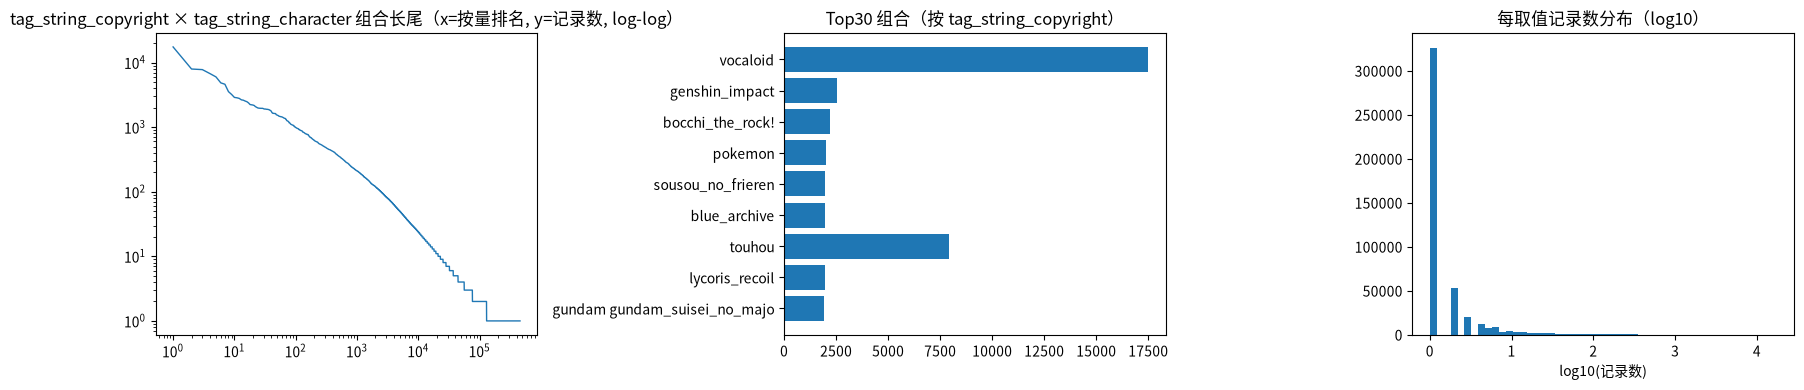

,copyright,character,n
0,vocaloid,hatsune_miku,17462
1,touhou,flandre_scarlet,7943
2,touhou,komeiji_koishi,7778
3,touhou,hakurei_reimu,6740
4,touhou,kirisame_marisa,6001
5,touhou,remilia_scarlet,4849
6,touhou,cirno,4615
7,touhou,hakurei_reimu kirisame_marisa,3547
8,touhou,konpaku_youmu konpaku_youmu_(ghost),3209
9,touhou,rumia,2887


· 取值过多（455,642），不建议直接按原始值均衡，先聚合/分桶（Top-K + 其余归一桶）
· Gini=0.728: 分布偏斜——均衡时注意头部占比
· Top1000 覆盖 28.3%: 长尾占比大，截断会丢较多信息


In [4]:
   # 'id': 'post 主键 ID', 'created_at': '上传时间', 'updated_at': '最后更新时间',
   # 'uploader_id': '上传者 ID', 'approver_id': '审核人 ID（未审核=null）',
   # 'score': '总分 = up_score - down_score', 'up_score': '顶数', 'down_score': '踩数', 'fav_count': '收藏数',
   # 'source': '原始来源 URL（pixiv 等）', 'pixiv_id': '关联 pixiv ID（无=null）',
   # 'md5': '图片内容 md5', 'file_ext': '文件扩展名', 'file_size': '文件大小（字节）',
   # 'image_width': '图片宽(px)', 'image_height': '图片高(px)',
   # 'rating': '分级：g/s/q/e（含义见下方枚举表）',
   # 'tag_string': '全部标签（空格分隔，带类型前缀）', 'tag_count': '标签总数',
   # 'tag_count_general': '一般标签数', 'tag_count_artist': '画师标签数',
   # 'tag_count_character': '角色标签数', 'tag_count_copyright': '作品标签数', 'tag_count_meta': '元标签数',
   # 'tag_string_general': '一般标签串', 'tag_string_character': '角色标签串',
   # 'tag_string_copyright': '作品标签串', 'tag_string_artist': '画师标签串', 'tag_string_meta': '元标签串',
   # 'parent_id': '父 post（系列/变体图，无=null）', 'has_children': '是否有子 post',
   # 'has_active_children': '是否有未删除的子 post', 'has_visible_children': '是否有可见子 post',
   # 'has_large': '是否有大图版本',
   # 'is_pending': '待审核', 'is_flagged': '被标记删除申请', 'is_deleted': '已删除', 'is_banned': '被封禁',
   # 'last_commented_at': '最后评论时间', 'last_comment_bumped_at': '最后评论 bump 时间',
   # 'last_noted_at': '最后翻译注释时间', 'bit_flags': '内部位标记',
   # 'file_url': '原图直链', 'large_file_url': '大图直链', 'preview_file_url': '预览图直链',
FILTER_SQL = "rating = 'g' and (tag_string_character IS NOT NULL and TRY_CAST(tag_string_character AS VARCHAR) != '') "   # ← 改这里：SQL WHERE 条件（duckdb 语法）

META_FILE = 'metadata.parquet'   # ← 改这里：换元数据文件
FIELD1     = 'tag_string_copyright'  
FIELD2     = 'tag_string_character'          # ← 改这里：要下钻的字段名（None=报错列出可选字段）

con.execute('DROP TABLE IF EXISTS vc')
con.execute(f"CREATE OR REPLACE VIEW m AS SELECT * FROM read_parquet('{BASE / META_FILE}') where {FILTER_SQL}")
cols = [r[0] for r in con.execute("SELECT column_name FROM (DESCRIBE SELECT * FROM m)").fetchall()]

# ---- 取值分布：总数 / 空值 / 取值数 / TopN 覆盖率 / Gini ----
N_ALL = con.execute('SELECT count(*) FROM m').fetchone()[0]
N_NA = con.execute(f"SELECT count(*) FROM m WHERE {FIELD1} IS NULL OR {FIELD2} IS NULL").fetchone()[0]

con.execute(f'''CREATE TABLE vc AS
    SELECT {FIELD1} AS copyright, {FIELD2} AS character, count(*) AS n
    FROM m GROUP BY 1,2''')

vc = con.execute('SELECT copyright, character, n FROM vc ORDER BY n DESC, copyright').df()
N_VC = len(vc)

TOT = vc.n.sum()
cov = lambda k: vc.n.head(k).sum() / TOT * 100

def gini(x):
    x = np.sort(np.asarray(x, float)); n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n

G = gini(vc.n.values)
print(f'总记录: {N_ALL:,}   空值: {N_NA:,} ({N_NA/max(TOT,1):.1%})   非空: {TOT-N_NA:,}')
print(f'取值总数: {N_VC:,}   Top10: {cov(10):.1f}%   Top100: {cov(100):.1f}%   Top1000: {cov(1000):.1f}%   Gini: {G:.3f}')
q = np.percentile(vc.n.values, [25, 50, 90])
print(f'每取值记录数: p25={q[0]:.0f}  p50={q[1]:.0f}  p90={q[2]:.0f}  最大={vc.n.max():,} ({vc.copyright.iloc[0]})')

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].loglog(np.arange(1, N_VC + 1), vc.n.values, lw=1)
axes[0].set_title(f'{FIELD1} × {FIELD2} 组合长尾（x=按量排名, y=记录数, log-log）')
top30 = vc.head(30)
axes[1].barh(top30.copyright.str.slice(0, 30)[::-1], top30.n.values[::-1])
axes[1].set_title(f'Top30 组合（按 {FIELD1}）')
axes[2].hist(np.log10(np.clip(vc.n.values, 1, None)), bins=50)
axes[2].set_title('每取值记录数分布（log10）')
axes[2].set_xlabel('log10(记录数)')
plt.tight_layout()
plt.show()
display(vc.head(30))


# ---- 均衡化适用性提示（启发式，供人工判断） ----
if N_VC <= 200:
    s = f'取值少（{N_VC:,}），可直接作为均衡化分层字段'
elif N_VC <= 10_000:
    s = f'取值中等（{N_VC:,}），可作均衡化字段；建议低频值（记录数<p25）合并或欠采样'
else:
    s = f'取值过多（{N_VC:,}），不建议直接按原始值均衡，先聚合/分桶（Top-K + 其余归一桶）'
print(f'· {s}')
print(f'· Gini={G:.3f}: ' + ('头部极集中，长尾严重——均衡需欠采样头部或加权采样' if G > 0.9 else
                          '分布偏斜——均衡时注意头部占比' if G > 0.7 else '分布较均衡'))
print(f'· Top1000 覆盖 {cov(1000):.1f}%: ' + ('头部即主体，截断 Top-K 损失小' if cov(1000) > 80 else '长尾占比大，截断会丢较多信息'))

### 抽样看 case

`SAMPLE_VALUES=None` 时自动取记录数 Top6 取值，每个取值抽 `SAMPLES_PER_VALUE` 条；卡片自动渲染 http 图（danbooru 走 preview_file_url CDN 缩略图），其余字段文本展示。

In [5]:

SAMPLE_VALUES     = None    # ← 改这里：指定要看的取值列表，如 ['hatsune_miku']；None=自动取记录数 Top6
SAMPLES_PER_VALUE = 4       # ← 改这里：每个取值抽几条
SAMPLE_FIELDS     = None    # ← 改这里：卡片显示哪些字段；None=自动（除置顶字段外前 8 个）
SAMPLE_FIELD      = FIELD2  # ← 改这里：按哪个字段置顶抽样（FIELD1 / FIELD2）
SAMPLE_FILTER     = "1=1"   # ← 改这里：抽样时的附加过滤条件（duckdb 语法；叠加在 cell 6 的 FILTER_SQL 之上）；"1=1"=不过滤

# ---- 按 SAMPLE_FIELD 现算取值分布（cell 6 的 vc 是 FIELD1×FIELD2 组合，此处按单字段重聚）----
vc_s = con.execute(
    f'''SELECT TRY_CAST({SAMPLE_FIELD} AS VARCHAR) AS v, count(*) AS n
        FROM m WHERE {SAMPLE_FILTER} GROUP BY 1 ORDER BY n DESC''').df()
vals = SAMPLE_VALUES if SAMPLE_VALUES is not None else vc_s.v[vc_s.v != '(null)'].head(6).tolist()
fields = SAMPLE_FIELDS or [c for c in cols if c != SAMPLE_FIELD][:8]
if SAMPLE_FIELD not in fields:
    fields = [SAMPLE_FIELD] + fields       # 置顶抽样字段

def card(r):
    img_html = ''
    for c in cols:
        v = r.get(c)
        if isinstance(v, str) and (v.startswith('http') or (BASE / v).is_file() or Path('..').joinpath(v).is_file()):
            src = v if v.startswith('http') else (v if (BASE / v).is_file() else str(Path('..') / v))
            img_html = f'<img src="{src}" loading="lazy" style="height:200px;max-width:260px;object-fit:contain;background:#f6f6f6">'
            break
    kv = ''.join(f'<div style="font-size:12px"><b>{c}</b>: {str(r.get(c))[:120]}</div>' for c in fields)
    return f'<td style="vertical-align:top;padding:6px;border:1px solid #ddd">{img_html}{kv}</td>'

for v in vals:
    sub = con.execute(
        f'''SELECT * FROM m
            WHERE {SAMPLE_FILTER}
              AND CASE WHEN {SAMPLE_FIELD} IS NULL OR TRY_CAST({SAMPLE_FIELD} AS VARCHAR) = ''
                       THEN '(null)' ELSE TRY_CAST({SAMPLE_FIELD} AS VARCHAR) END = ?
            LIMIT 4000''', [v]).df().sample(min(SAMPLES_PER_VALUE, 4000), random_state=42)
    if len(sub) == 0:
        print(f'取值不存在: {v}')
        continue
    display(HTML(f'<h4>{SAMPLE_FIELD} = {str(v)[:80]}（全量 {int(vc_s.n[vc_s.v==v].iloc[0]) if (vc_s.v==v).any() else "?"} 条，抽样 {len(sub)}）</h4>'))
    trs = ['<tr>' + ''.join(card(r) for r in sub[i:i+4].to_dict('records')) + '</tr>' for i in range(0, len(sub), 4)]
    display(HTML('<table style="border-collapse:collapse">' + ''.join(trs) + '</table>'))


tag_string_character: hatsune_mikucreated_at: 2008-01-07T05:41:41.867-05:00uploader_id: 11077score: 2source: http://aright-oon.hp.infoseek.co.jp/strat.jpgmd5: 0714ee4b30503976fc9393de4b3bd1b3last_comment_bumped_at: nanrating: gimage_width: 800,tag_string_character: hatsune_mikucreated_at: 2009-08-28T18:50:05.589-04:00uploader_id: 12866score: 3source: http://www.geocities.jp/excalibur_resemble/highend_miku.jpgmd5: 13d39e95508c26f6b6363030dba535f4last_comment_bumped_at: nanrating: gimage_width: 1050,tag_string_character: hatsune_mikucreated_at: 2008-01-01T00:32:01.582-05:00uploader_id: 14036score: 3source: https://i.pximg.net/img-original/img/2007/09/30/13/41/09/37343_p0.jpgmd5: 520ed900e611fc700626f43d761a01c1last_comment_bumped_at: nanrating: gimage_width: 600,tag_string_character: hatsune_mikucreated_at: 2009-10-18T18:27:14.340-04:00uploader_id: 17169score: 2source: https://i.pximg.net/img-original/img/2009/07/03/05/26/42/4977887_p0.jpgmd5: ed20f48b5bc9534e9f4e3c1b31c823d0last_comment_bumped_at: nanrating: gimage_width: 2480


tag_string_character: flandre_scarletcreated_at: 2011-07-25T00:37:32.724-04:00uploader_id: 348377score: 1source: http://img04.pixiv.net/img/aenobas/19955002_big_p29.jpgmd5: ad4d87d2227a7a6d130e00efac21f7cblast_comment_bumped_at: nanrating: gimage_width: 800,tag_string_character: flandre_scarletcreated_at: 2022-08-20T08:57:23.434-04:00uploader_id: 808454score: 15source: https://twitter.com/R_Utchi/status/1560941511130624000md5: fbb0e84312a14b41f8c1ecaf95975d29last_comment_bumped_at: nanrating: gimage_width: 2894,tag_string_character: flandre_scarletcreated_at: 2011-06-16T20:41:43.994-04:00uploader_id: 23260score: 7source: https://i.pximg.net/img-original/img/2011/06/17/09/28/10/19686939_p0.pngmd5: afc9cadd7719fd5926f3f641b437588elast_comment_bumped_at: nanrating: gimage_width: 500,tag_string_character: flandre_scarletcreated_at: 2022-11-21T14:39:48.323-05:00uploader_id: 200729score: 10source: https://i.pximg.net/img-original/img/2022/11/02/00/52/51/102438976_p1.pngmd5: 4c322f19041a152576c4d5c31b25f3dflast_comment_bumped_at: nanrating: gimage_width: 2276


tag_string_character: komeiji_koishicreated_at: 2013-05-13T17:54:51.838-04:00uploader_id: 13047score: 12source: https://i.pximg.net/img-original/img/2013/05/14/06/09/02/35685134_p0.jpgmd5: 69539d88fedea1606c077f757357e966last_comment_bumped_at: nanrating: gimage_width: 700,tag_string_character: komeiji_koishicreated_at: 2022-07-12T20:15:49.644-04:00uploader_id: 807296score: 17source: https://twitter.com/mari_fumo/status/1546857116266283010md5: 4f0a93efbfed6d290eaddac42bc826eblast_comment_bumped_at: nanrating: gimage_width: 1716,tag_string_character: komeiji_koishicreated_at: 2013-03-19T00:46:31.325-04:00uploader_id: 372510score: 5source: https://yogurtmedia.tumblr.com/post/45732863347md5: 3b1085e303d6de3dd59db7faa0961906last_comment_bumped_at: nanrating: gimage_width: 1280,tag_string_character: komeiji_koishicreated_at: 2022-11-04T19:45:00.542-04:00uploader_id: 483749score: 24source: https://i.pximg.net/img-original/img/2022/11/05/02/58/13/102521120_p0.jpgmd5: 5c56fe0c8a62868d0d61e6e4e8a87666last_comment_bumped_at: nanrating: gimage_width: 2751


tag_string_character: hakurei_reimucreated_at: 2009-02-26T04:30:42.775-05:00uploader_id: 49984score: 5source: https://i.pximg.net/img-original/img/2009/01/17/17/54/07/2763498_p0.jpgmd5: 4e2bd0bd564809053f918efc34cd1387last_comment_bumped_at: 2010-08-17T13:50:49.205-04:00rating: gimage_width: 777,tag_string_character: hakurei_reimucreated_at: 2022-03-20T13:13:22.213-04:00uploader_id: 721942score: 11source: https://twitter.com/simerike5/status/1505486203105079296md5: 0c17fa8b007f1dfaae5617d5e5fafa23last_comment_bumped_at: nanrating: gimage_width: 1200,tag_string_character: hakurei_reimucreated_at: 2009-02-08T16:29:17.197-05:00uploader_id: 10863score: 4source: https://i.pximg.net/img-original/img/2009/02/09/09/28/56/3026431_p0.jpgmd5: bc6a115063eb011712a11e16751de003last_comment_bumped_at: 2011-11-10T09:53:29.435-05:00rating: gimage_width: 669,"<img src=""https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/e6088841-0279-4ea3-a66b-c30026b3548a/df4iqs6-bc2da78d-a3c9-4de6-8a78-6cbd1905f0e0.png?token=eyJ0eXAiOiJKV1QiLCJhbGciOiJub25lIn0.eyJzdWIiOiJ1cm46YXBwOiIsImlzcyI6InVybjphcHA6Iiwib2JqIjpbW3sicGF0aCI6Ii9mL2U2MDg4ODQxLTAyNzktNGVhMy1hNjZiLWMzMDAyNmIzNTQ4YS9kZjRpcXM2LWJjMmRhNzhkLWEzYzktNGRlNi04YTc4LTZjYmQxOTA1ZjBlMC5wbmcifV1dLCJhdWQiOlsidXJuOnNlcnZpY2U6ZmlsZS5kb3dubG9hZCJdfQ."" loading=""lazy"" style=""height:200px;max-width:260px;object-fit:contain;background:#f6f6f6"">tag_string_character: hakurei_reimucreated_at: 2022-06-18T17:01:14.220-04:00uploader_id: 337979score: 18source: https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/e6088841-0279-4ea3-a66b-c30026b3548a/df4iqs6-bc2da78d-a3c9-4demd5: 7661483391e530898cdd8b99b392fb13last_comment_bumped_at: nanrating: gimage_width: 1700"


tag_string_character: kirisame_marisacreated_at: 2009-01-18T17:46:31.657-05:00uploader_id: 27222score: 4source: https://i.pximg.net/img-original/img/2008/04/08/03/44/27/638923_p0.jpgmd5: cfe3cc0fc66710d5bd8de91e4481c3c8last_comment_bumped_at: nanrating: gimage_width: 500,tag_string_character: kirisame_marisacreated_at: 2022-03-20T11:21:34.322-04:00uploader_id: 721942score: 47source: https://i.pximg.net/img-original/img/2022/03/20/19/48/30/97051416_p0.jpgmd5: e280b9c5c4897bf3d4b72ec6d0bfb3b3last_comment_bumped_at: 2024-08-25T06:48:44.502-04:00rating: gimage_width: 2894,tag_string_character: kirisame_marisacreated_at: 2008-12-08T02:34:50.975-05:00uploader_id: 1309score: 14source: https://i.pximg.net/img-original/img/2008/12/08/19/19/48/2346626_p0.pngmd5: 47c3894320afb7629867ec4cfe8a4e23last_comment_bumped_at: 2019-04-19T19:09:41.032-04:00rating: gimage_width: 1000,tag_string_character: kirisame_marisacreated_at: 2022-07-22T08:25:03.606-04:00uploader_id: 808454score: 5source: https://twitter.com/gyokuourou4414/status/1550386157749297152md5: 5dc8314ba4679babbc36b38b056c8cf4last_comment_bumped_at: nanrating: gimage_width: 3088


tag_string_character: remilia_scarletcreated_at: 2010-06-18T06:33:59.643-04:00uploader_id: 61214score: 7source: http://s1-03.twitpicproxy.com/photos/full/109168118.pngmd5: 3356d3127f202017c6d54551d8d2524clast_comment_bumped_at: 2011-08-28T09:48:15.835-04:00rating: gimage_width: 501,tag_string_character: remilia_scarletcreated_at: 2023-03-26T02:40:52.285-04:00uploader_id: 766411score: 20source: https://i.pximg.net/img-original/img/2022/05/19/15/25/46/98450643_p0.jpgmd5: fef1232f828cde63314aa313a146b256last_comment_bumped_at: nanrating: gimage_width: 2480,tag_string_character: remilia_scarletcreated_at: 2010-03-17T18:27:29.096-04:00uploader_id: 1score: 15source: http://file.kimtaru.blog.shinobi.jp/0aa8799c.jpgmd5: 1decfe068b06fbdc422811945abca015last_comment_bumped_at: nanrating: gimage_width: 550,tag_string_character: remilia_scarletcreated_at: 2023-09-17T20:06:53.099-04:00uploader_id: 454016score: 27source: https://i.pximg.net/img-original/img/2021/03/28/14/41/45/88760549_p0.jpgmd5: 6f482fcfbb3bae67f24bf3a80943ca43last_comment_bumped_at: nanrating: gimage_width: 2894


## 目标数据分布

metadata.jsonl 全表 192,449 条
metadata.jsonl 实例数 50,196 条


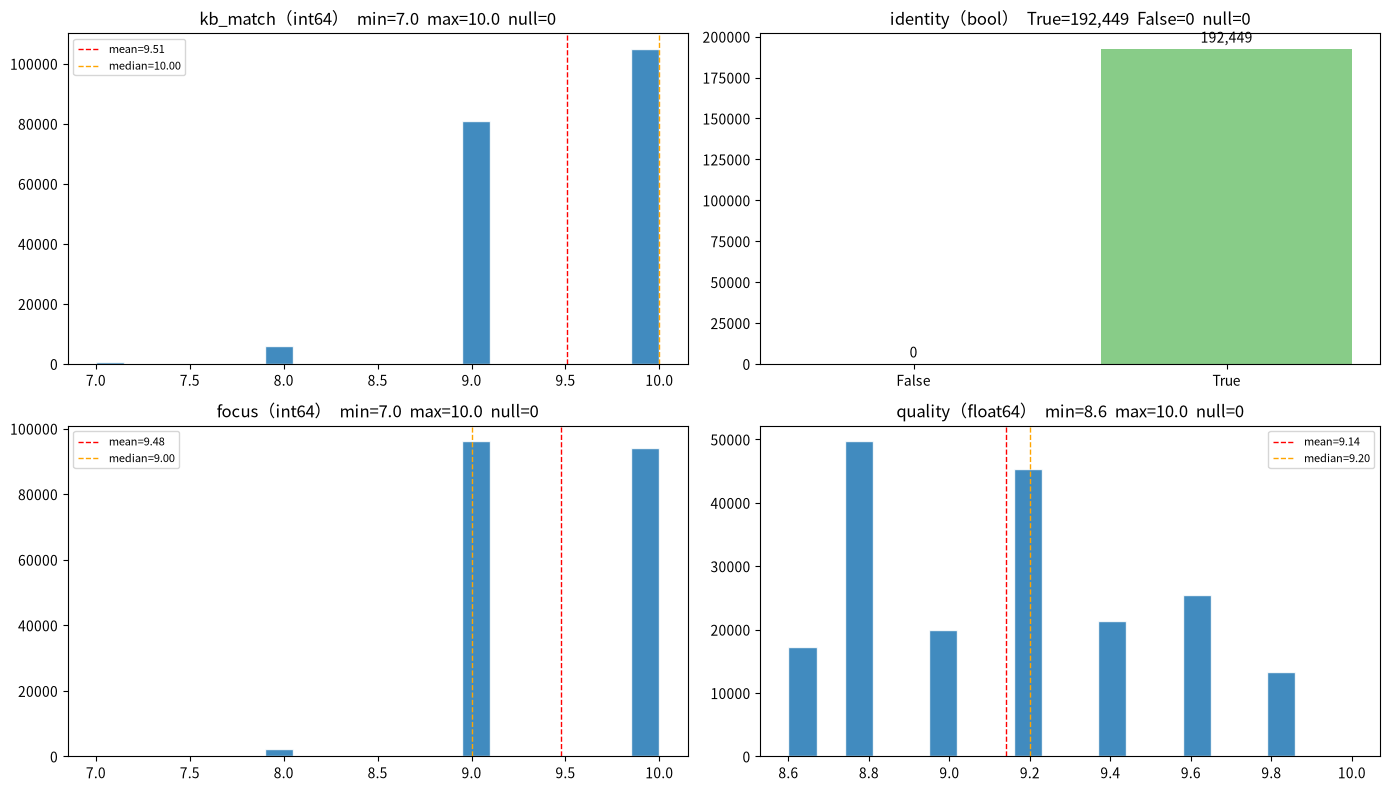

In [26]:
M_BASE   = Path('../data/datasets/demiwtg')                    # 写死 demiwtg
M_META   = M_BASE / 'meta' / 'metadata.jsonl'                  # 写死清单路径
SOURCE   = None   # ← 改这里：migrate 部分；None=不限来源
N_SAMPLE = 8                   # ← 改这里：抽几条
FIELDS   = None                # ← 改这里：卡片字段；None=默认（迁移关注面）

mcon = duckdb.connect()


# ---- 读全表到 pandas（后续分布/过滤都基于它；复用部件三的 mcon / M_BASE）----
# ---- 过滤看 case ----
# metadata.jsonl 可用字段：
#   sha256(str)  ext(str)  source(str)  license(str)  author(str|None)
#   content_url(str)  landing_url(str|None)  path(str)  mime(str|None)
#   fetched_at(float)  size_bytes(int)  width(int)  height(int)
#   orig_width(int|None)  orig_height(int|None)
#   instances(list[str])  queries(dict)  query_langs(dict)
#   kb_match(int 0-10)  richness(int)  identity(bool)  focus(int 0-10)
#   quality(float 0-10)  caption(str|None)
FILTER_SQL = "quality >=8.5 and identity=true "   # ← 改这里：SQL WHERE 条件（duckdb 语法）
# 示例：
#   "kb_match >= 5 AND identity = true"
#   "source IN ('pixiv', 'anilist') AND quality >= 7"
#   "width >= 512 AND height >= 512 AND richness >= 5"
#   "instances[1] = '初音未来' AND kb_match >= 6"
#   "1=1"  -- 不过滤，全量
N_CASES = 8                     # ← 改这里：抽几条

mdf = mcon.execute(f"SELECT * FROM read_json_auto('{M_META}', maximum_object_size=1073741824)  WHERE {FILTER_SQL}").df()
print(f'metadata.jsonl 全表 {len(mdf):,} 条')

midf = mcon.execute(f"SELECT instances[1],count(*) FROM read_json_auto('{M_META}', maximum_object_size=1073741824)  WHERE {FILTER_SQL} group by 1").df()
print(f'metadata.jsonl 实例数 {len(midf):,} 条')


SCORE_FIELDS = ['kb_match', 'identity', 'focus', 'quality']   # ← 改这里：要看的打分字段
N_BINS = 21                                                    # ← 改这里：直方图分箱数

# ---- 分布 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, field in zip(axes.ravel(), SCORE_FIELDS):
    vals = mdf[field].dropna()
    n_total = len(mdf)
    n_na = n_total - len(vals)
    if field == 'identity':
        tc = int(vals.sum())
        fc = len(vals) - tc
        ax.bar(['False', 'True'], [fc, tc], color=['#e88', '#8c8'])
        ax.set_title(f'{field}（bool）  True={tc:,}  False={fc:,}  null={n_na:,}')
        for i, v in enumerate([fc, tc]):
            ax.text(i, v + max(fc, tc) * 0.02, f'{v:,}', ha='center', fontsize=10)
    else:
        lo, hi = float(vals.min()), float(vals.max())
        if hi - lo < 1e-9:
            ax.text(0.5, 0.5, f'{field}\n唯一值={lo}', ha='center', va='center', transform=ax.transAxes)
        else:
            bins = np.linspace(lo, hi, N_BINS)
            ax.hist(vals, bins=bins, edgecolor='white', alpha=0.85)
            mean_v, med_v = vals.mean(), vals.median()
            ax.axvline(mean_v, color='red', ls='--', lw=1, label=f'mean={mean_v:.2f}')
            ax.axvline(med_v, color='orange', ls='--', lw=1, label=f'median={med_v:.2f}')
            ax.legend(fontsize=8)
            ax.set_title(f'{field}（{vals.dtype}）  min={lo}  max={hi}  null={n_na:,}')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


,条数,kb_match,focus,quality,richness,identity%,占比%
source,,,,,,,
bing_images,73441,9.54,9.47,9.17,7.82,100.0,38.2
baidu,42309,9.55,9.49,9.13,7.58,100.0,22.0
so360,36541,9.52,9.47,9.12,7.63,100.0,19.0
huaban_api,20117,9.39,9.48,9.13,7.91,100.0,10.5
toutiao,11954,9.38,9.40,9.04,7.65,100.0,6.2
yandex_images,3779,9.53,9.58,9.21,7.83,100.0,2.0
wikimedia,1344,9.42,9.44,9.11,7.86,100.0,0.7
wikimedia_zh,885,9.46,9.45,9.09,7.64,100.0,0.5
pixiv,565,9.06,9.54,9.03,7.97,100.0,0.3


/tank/tmp/ipykernel_3156989/1244698353.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, showfliers=False, widths=0.6)
/tank/tmp/ipykernel_3156989/1244698353.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, showfliers=False, widths=0.6)
/tank/tmp/ipykernel_3156989/1244698353.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, showfliers=False, widths=0.6)
/tank/tmp/ipykernel_3156989/1244698353.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.

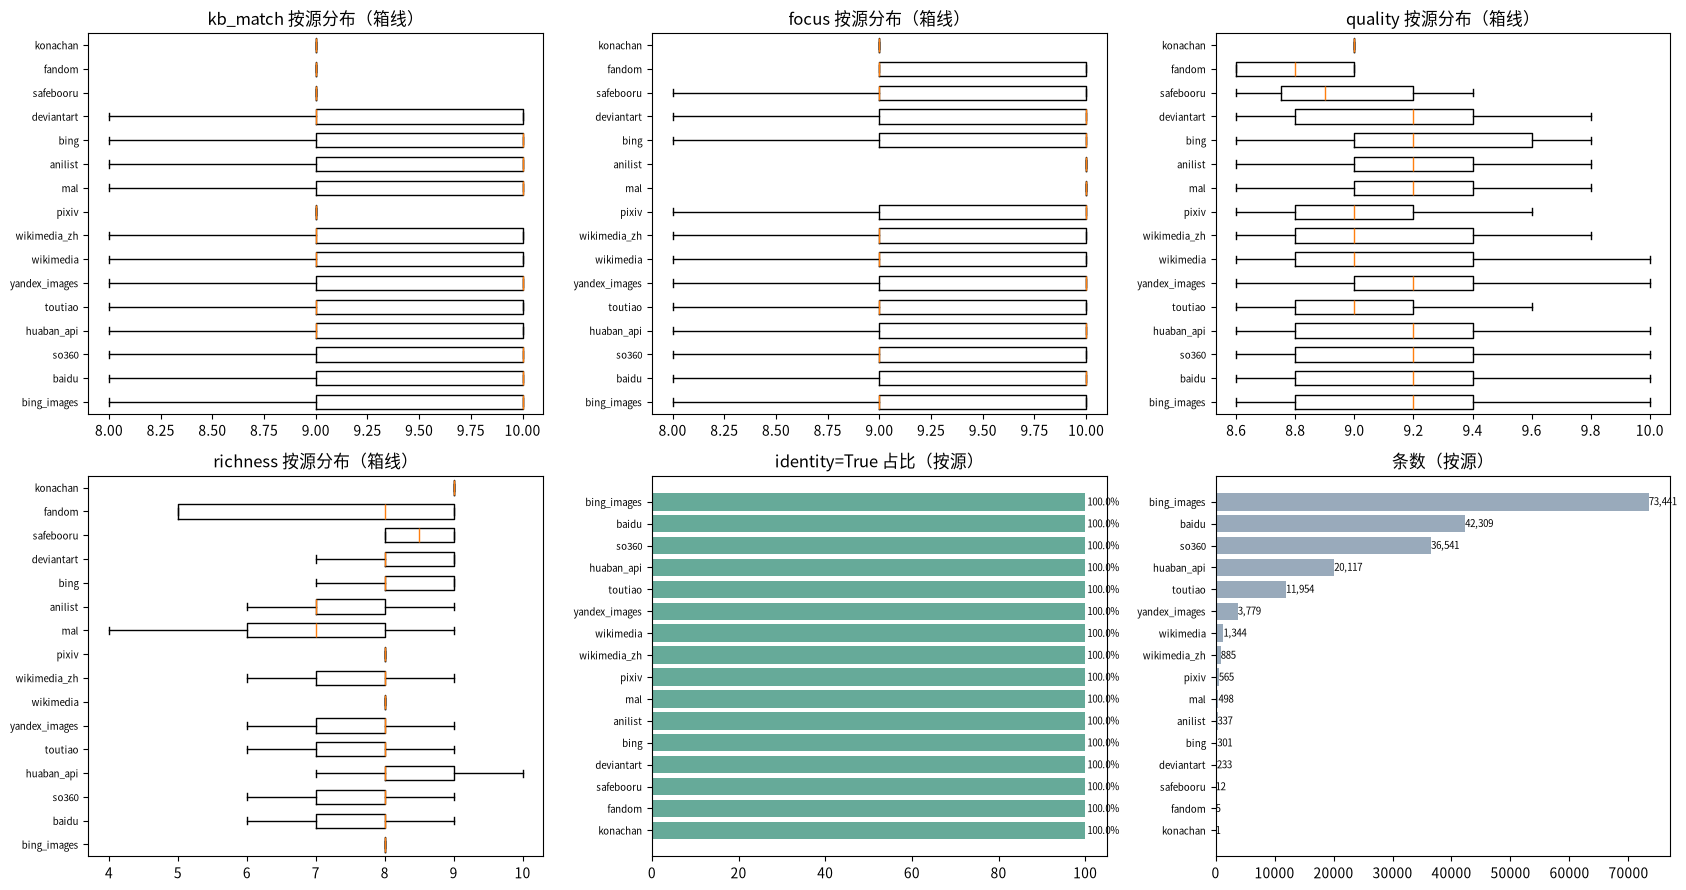

In [18]:

# ---- 每个数据源的各项得分 + identity 分布 ----
SCORE_COLS = ['kb_match', 'focus', 'quality', 'richness']   # ← 改这里：要对比的打分字段

g = mdf.groupby('source')
stat = pd.DataFrame({
    '条数': g.size(),
    **{c: g[c].mean().round(2) for c in SCORE_COLS},
    'identity%': (100 * g['identity'].apply(lambda s: (s == True).sum())
                  / g['identity'].apply(lambda s: s.notna().sum()).clip(lower=1)).round(1),
})
stat['占比%'] = (100 * stat['条数'] / stat['条数'].sum()).round(1)
stat = stat.sort_values('条数', ascending=False)
with pd.option_context('display.width', 200):
    display(stat)

order = list(stat.index)   # 按条数降序
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel()[:4], SCORE_COLS):
    data = [mdf.loc[mdf['source'] == s, col].dropna().values for s in order]
    ax.boxplot(data, vert=False, showfliers=False, widths=0.6)
    ax.set_yticks(range(1, len(order) + 1), order, fontsize=7)
    ax.set_title(f'{col} 按源分布（箱线）')
ax = axes[1][1]   # identity True 率
vals = stat.loc[order[::-1], 'identity%']
ax.barh(range(len(order)), vals, color='#6a9')
ax.set_yticks(range(len(order)), order[::-1], fontsize=7)
for i, v in enumerate(vals):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=7)
ax.set_title('identity=True 占比（按源）')
ax = axes[1][2]   # 条数占比
vals = stat.loc[order[::-1], '条数']
ax.barh(range(len(order)), vals, color='#9ab')
ax.set_yticks(range(len(order)), order[::-1], fontsize=7)
for i, v in enumerate(vals):
    ax.text(v, i, f'{v:,}', va='center', fontsize=7)
ax.set_title('条数（按源）')
plt.tight_layout()
plt.show()


## 多实例与重复检查

In [ ]:
# ---- 多实例与 (图, instance) 重复检查 ----
# metadata.jsonl 为记录驱动迁移产物：每实例×图一行，去重键 (sha256, instance)
N_CASES_MULTI = 1   # ← 改这里：多实例图抽几张
N_CASES_DUP   = 1    # ← 改这里：重复 (图, instance) 键抽几个

FILTER_SQL = "quality >=8.5 and identity=true "  

md = mcon.execute(
    f"SELECT sha256, instances FROM read_json_auto('{M_META}', maximum_object_size=1073741824) where {FILTER_SQL}").df()
pairs = md.explode('instances').rename(columns={'instances': 'instance'})
pairs = pairs[pairs.instance.notna()]
n_rows, n_imgs = len(md), md.sha256.nunique()

per_img = pairs.groupby('sha256')['instance'].agg(['nunique', 'size'])
multi = per_img[per_img['nunique'] > 1]                    # 挂了 2+ 个不同实例的图
key_cnt = pairs.value_counts(['sha256', 'instance'])
dup = key_cnt[key_cnt > 1]                                 # 出现 2+ 次的 (图, instance) 键
n_extra = int(dup.sum() - len(dup))                        # 按去重键算多出来的冗余行

print(f'总行数: {n_rows:,}   去重图片数: {n_imgs:,}   去重 (图,instance) 键数: {len(key_cnt):,}')
print(f'多实例图片: {len(multi):,} ({len(multi)/max(n_imgs,1):.1%} of 图片)')
print('实例数分布: ' + '  '.join(f'{k} 个实例: {v:,} 张' for k, v in multi['nunique'].value_counts().sort_index().items()))
print(f'重复 (图,instance): {len(dup):,} 个键, 冗余行 {n_extra:,} ({n_extra/max(n_rows,1):.1%} of 总行数)')

# ---- 抽样卡片：一图一卡，逐行列出该行 instance 与打分 ----
show_fields = ['instances', 'source', 'kb_match', 'identity', 'focus', 'quality', 'caption']

def cards_of(shas):
    in_list = ','.join(f"'{s}'" for s in shas)
    fsub = mcon.execute(
        f"SELECT * FROM read_json_auto('{M_META}', maximum_object_size=1073741824) WHERE sha256 IN ({in_list}) and {FILTER_SQL}").df()
    for sha, grp in fsub.sort_values('source').groupby('sha256', sort=False):
        r0 = grp.iloc[0]
        ip = M_BASE / r0['path'] if isinstance(r0.get('path'), str) and (M_BASE / r0['path']).is_file() else None
        img = (f'<img src="{ip}" loading="lazy" style="max-height:280px;max-width:380px;object-fit:contain;background:#f6f6f6">'
               if ip else '<div style="color:#c00">blob 缺失</div>')
        rows = ''.join('<div style="border-top:1px dashed #ccc;padding:4px 0">'
                       + ''.join(f'<div style="font-size:12px;margin:1px 0"><b>{c}</b>: {str(r.get(c))[:220]}</div>'
                                 for c in show_fields) + '</div>'
                       for _, r in grp.iterrows())
        display(HTML(f'<div style="display:flex;gap:12px;border:1px solid #ddd;padding:8px;margin:8px 0;align-items:flex-start">'
                     f'{img}<div style="min-width:0"><b>{sha[:16]}…</b>（{len(grp)} 行）{rows}</div></div>'))

if len(multi):
    shas = list(pd.Series(multi.index).sample(min(N_CASES_MULTI, len(multi)), random_state=42))
    print(f'\n===== 多实例图片抽样（{len(shas)} 张）=====')
    cards_of(shas)
else:
    print('\n无多实例图片')

if len(dup):
    keys = dup.index.to_series().sample(min(N_CASES_DUP, len(dup)), random_state=42)
    print(f'\n===== 重复 (图,instance) 抽样（{len(keys)} 键，展示对应图的全部行）=====')
    for k in keys:
        print(f'  {k[0][:16]}… × {k[1]}  → {int(dup.loc[k])} 行')
    cards_of(list(dict.fromkeys(k[0] for k in keys)))
else:
    print('\n无重复 (图,instance)')


总行数: 192,323   去重图片数: 185,758   去重 (图,instance) 键数: 192,289
多实例图片: 5,715 (3.1% of 图片)
实例数分布: 2 个实例: 5,123 张  3 个实例: 476 张  4 个实例: 82 张  5 个实例: 20 张  6 个实例: 5 张  7 个实例: 2 张  8 个实例: 1 张  10 个实例: 1 张  12 个实例: 1 张  14 个实例: 1 张  17 个实例: 1 张  19 个实例: 1 张  20 个实例: 1 张
重复 (图,instance): 34 个键, 冗余行 34 (0.0% of 总行数)

===== 多实例图片抽样（8 张）=====



===== 重复 (图,instance) 抽样（8 键，展示对应图的全部行）=====
  fc9cdb5f24b4161f… × 康熙  → 2 行
  decc7bf296e11b55… × 特莉丝  → 2 行
  e33736fceb2b1f2a… × 小医仙  → 2 行
  ed31da886a366815… × 城隍爷  → 2 行
  b9e7bde9bb2a643e… × 闻仲  → 2 行
  db75ce88e9380fa7… × 稻草人  → 2 行
  b5f9c06c964edffe… × 契妮  → 2 行
  9f553531458fbfdd… × 花荣  → 2 行


实例总数: 58,229（清单内 53,226 + 0 图 5,003）
每实例图数: 中位 4  均值 4.4  max 29
0 张: 5,003   仅 1 张: 6,008   <2 张: 11,011   ≥8 张(--skip-covered 阈值): 5,986
覆盖档分布: 0 张: 5,003   1 张: 6,008   2-7 张: 41,232   >=8 张: 5,986


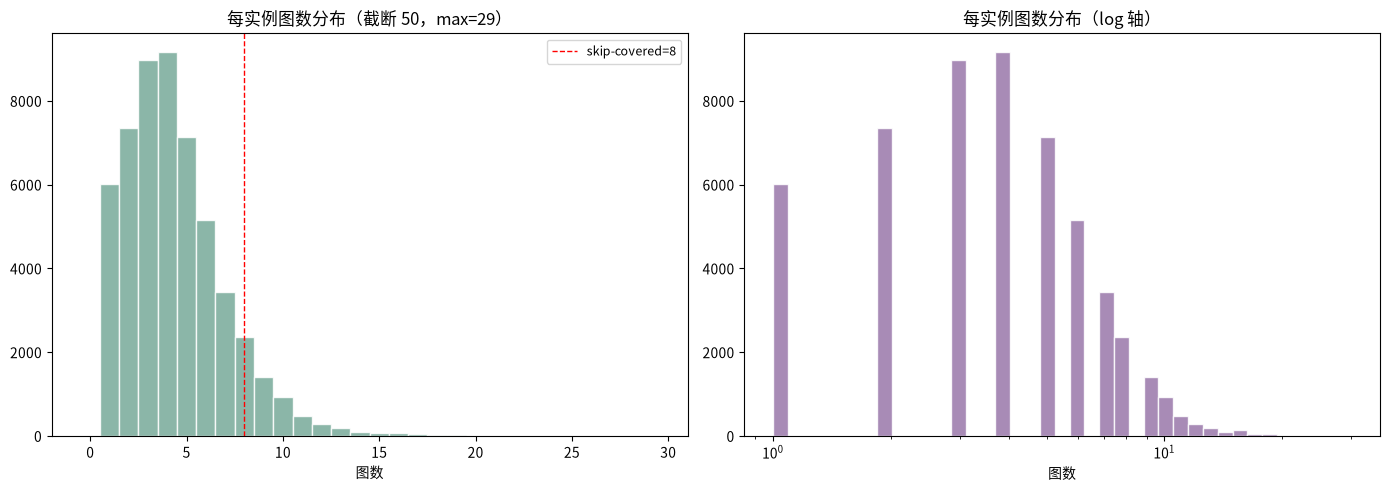

In [25]:
# ---- 每实例图数分布（多图分布；复用 M_META / M_BASE / FILTER_SQL）----
# 口径与 collect_v2 覆盖算子一致：每清单行给行内每个实例各计一张（跨实例不共享）
import json as _json
import duckdb

FILT = (FILTER_SQL or "1=1").strip() or "1=1"
icon = duckdb.connect()          # 独立连接，不污染部件三的 mcon
pairs = icon.execute(f"""
    SELECT unnest(instances) AS instance
    FROM read_json_auto('{M_META}', maximum_object_size=1073741824)
    WHERE {FILT}
""").df()
pairs = pairs[pairs.instance.notna()]
cnt = pairs.groupby('instance').size()

with open(M_BASE / 'meta' / 'instances.json', encoding='utf-8') as f:
    all_names = {i['name'] for i in _json.load(f)['instances']}
n_zero = len(all_names - set(cnt.index))          # 实例表有、清单无 → 0 图

total = len(cnt) + n_zero
med, mean = cnt.median(), cnt.mean()
print(f'实例总数: {total:,}（清单内 {len(cnt):,} + 0 图 {n_zero:,}）')
print(f'每实例图数: 中位 {med:.0f}  均值 {mean:.1f}  max {int(cnt.max())}')
print(f'0 张: {n_zero:,}   仅 1 张: {int((cnt == 1).sum()):,}   <2 张: {n_zero + int((cnt == 1).sum()):,}'
      f'   ≥8 张(--skip-covered 阈值): {int((cnt >= 8).sum()):,}')

bins = pd.cut(cnt, bins=[-1, 0, 1, 7, 10**9],
              labels=['0', '1', '2-7', '>=8']).value_counts().reindex(['0', '1', '2-7', '>=8']).fillna(0)
bins['0'] += n_zero
print('覆盖档分布: ' + '   '.join(f'{k} 张: {v:,}' for k, v in bins.items()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
CAP = 50                       # ← 改这里：线性直方图截断上限（尾部并进末柱）
ax = axes[0]
vals = cnt[cnt <= CAP].values
hi = min(CAP, max(int(vals.max()), 1))
ax.hist(vals, bins=np.arange(0, hi + 2) - 0.5, edgecolor='white', color='#7a9', alpha=0.85)
ax.axvline(8, color='red', ls='--', lw=1, label='skip-covered=8')
ax.legend(fontsize=9)
ax.set_title(f'每实例图数分布（截断 {CAP}，max={int(cnt.max())}）')
ax.set_xlabel('图数')
ax = axes[1]                   # 对数轴看全尾部：长尾/重尾一眼辨
ax.hist(cnt.values, bins=np.logspace(0, np.log10(cnt.max() + 1), 40),
        edgecolor='white', color='#97a', alpha=0.85)
ax.set_xscale('log')
ax.set_title('每实例图数分布（log 轴）')
ax.set_xlabel('图数')
plt.tight_layout()
plt.show()


## 目标数据抽样

In [21]:
# ---- 过滤看 case ----
# metadata.jsonl 可用字段：
#   sha256(str)  ext(str)  source(str)  license(str)  author(str|None)
#   content_url(str)  landing_url(str|None)  path(str)  mime(str|None)
#   fetched_at(float)  size_bytes(int)  width(int)  height(int)
#   orig_width(int|None)  orig_height(int|None)
#   instances(list[str])  queries(dict)  query_langs(dict)
#   kb_match(int 0-10)  richness(int)  identity(bool)  focus(int 0-10)
#   quality(float 0-10)  caption(str|None)
FILTER_SQL = "quality >= 8 AND identity = true"  
# 示例：
#   "quality >= 8 AND identity = true"
#   "source IN ('pixiv', 'anilist') AND quality >= 7"
#   "width >= 512 AND height >= 512 AND richness >= 5"
#   "instances[1] = '初音未来' AND kb_match >= 6"
#   "1=1"  -- 不过滤，全量
N_CASES = 8                     # ← 改这里：抽几条

fsub = mcon.execute(f"SELECT * FROM read_json_auto('{M_META}', maximum_object_size=1073741824) WHERE {FILTER_SQL}").df()
print(f'过滤: WHERE {FILTER_SQL}  →  命中 {len(fsub):,} 条（展示 {min(N_CASES, len(fsub))} 条）')
fsub = fsub.sample(min(N_CASES, len(fsub)), random_state=42)

show_fields = ['instances', 'source', 'kb_match', 'identity', 'focus', 'quality', 'caption']
for _, r in fsub.iterrows():
    ip = M_BASE / r['path'] if isinstance(r.get('path'), str) and (M_BASE / r['path']).is_file() else None
    img = (f'<img src="{ip}" loading="lazy" style="max-height:280px;max-width:380px;object-fit:contain;background:#f6f6f6">'
           if ip else '<div style="color:#c00">blob 缺失</div>')
    kv = ''.join(f'<div style="font-size:12px;margin:1px 0"><b>{c}</b>: {str(r.get(c))[:220]}</div>' for c in show_fields)
    display(HTML(f'<div style="display:flex;gap:12px;border:1px solid #ddd;padding:8px;margin:8px 0;align-items:flex-start">'
                 f'{img}<div style="min-width:0">{kv}</div></div>'))

过滤: WHERE quality >= 8 AND identity = true  →  命中 232,286 条（展示 8 条）


## 按 taxonomy 视角

把目标清单的 instance 打标挂回标签体系：挂载关系从 `meta/taxonomy.json` 现场聚合（复用 `taxonomy/mount_map.py`，不落盘）。按树深度聚合看各节点数据量，可限定子树、按节点抽样看图；三种全量导出均默认落 `state/curation/`（置 None 关闭）：`EXPORT_FILE`（按深度聚合表）、`EXPORT_TREE_FILE`（实例清单，节点×实例×图片数）、`EXPORT_TREE_FULL_FILE`（完整树，一行一节点，叶子附合并去重的采集 source 清单）。

In [22]:
# ---- taxonomy 视角：instance → 挂载路径从 taxonomy.json 现场聚合（mount_map 契约）----
TAX_DEPTH  = 4        # ← 改这里：按哪一层树深度聚合（根=0；越小越粗）
NODE_PATH  = None     # ← 改这里：只看某节点子树，如 '融合世界标签体系 / IP 分类标签 / 虚构角色 IP'；None=整棵树
FILTER_SQL = "quality >= 8 AND identity = true"  
EXPORT_FILE = Path('../state/curation/taxonomy_per_node.csv')   # ← 改这里：全量表导出路径；None=不导出
EXPORT_TREE_FILE = Path('../state/curation/taxonomy_tree_instances.csv')   # ← 改这里：实例清单树（一行一节点，叶子带实例名单）导出；None=不导出
EXPORT_TREE_FULL_FILE = Path('../state/curation/taxonomy_tree_full.csv')   # ← 改这里：完整树（一行一节点，叶子带实例 source 清单）导出；None=不导出

import sys
sys.path.insert(0, str(Path('..').resolve()))
from taxonomy.mount_map import load_mount_map, tree_sibling_of

mounts = load_mount_map(tree_sibling_of(str(M_META)))   # {实例名: [挂载节点路径, ...]}
print(f'taxonomy: {len(mounts):,} 个实例有挂载点')

mdt = mcon.execute(
    f"SELECT sha256, instances FROM read_json_auto('{M_META}', maximum_object_size=1073741824) WHERE {FILTER_SQL}").df()
tp = mdt.explode('instances').rename(columns={'instances': 'instance'})
tp['paths'] = tp['instance'].map(mounts)
unmounted = tp[tp.paths.isna()]
tp = tp[tp.paths.notna()].explode('paths')        # 一处挂载记一行；一图多挂载会重复计入各节点
if NODE_PATH:
    tp = tp[tp.paths.str.startswith(NODE_PATH)]
tp['node'] = tp.paths.str.split(' / ').str[:TAX_DEPTH + 1].str.join(' / ')

per_node = tp.groupby('node').agg(
    行数=('sha256', 'size'), 图片数=('sha256', 'nunique'), 实例数=('instance', 'nunique'))
per_node['占比%'] = (100 * per_node.行数 / max(len(tp), 1)).round(1)
per_node = per_node.sort_values('行数', ascending=False)

from IPython.display import FileLink   # notebook 里生成可点击下载链接（相对 notebook 所在目录）
def _dl_link(p):
    display(FileLink(str(p), result_html_prefix='下载: '))

# ---- 导出全量表格（不止 head(30)；utf-8-sig 供 Excel 直接打开）----
if EXPORT_FILE is not None:
    EXPORT_FILE.parent.mkdir(parents=True, exist_ok=True)
    out = per_node.reset_index().rename(columns={'node': 'node_path'})
    out.insert(1, 'depth', out.node_path.str.count(' / '))
    out.to_csv(EXPORT_FILE, index=False, encoding='utf-8-sig')
    print(f'全量表已导出: {len(out):,} 行 → {EXPORT_FILE.resolve()}')

# ---- 导出实例清单树（与 taxonomy_tree_full.csv 同构：一行一节点；叶子带挂载实例名单，| 分隔）----
if EXPORT_TREE_FILE is not None:
    import json as _json
    tree = _json.load(open(tree_sibling_of(str(M_META)), encoding='utf-8'))['tree']
    rows = []
    def walk(n):
        is_leaf = not (n.get('children') or [])
        insts = [(i.get('name') if isinstance(i, dict) else i) for i in (n.get('instances') or [])]
        insts = [str(i).strip() for i in insts if i is not None and str(i).strip()]
        # 与 taxonomy_tree_full.csv 同构：一行一节点；叶子带挂载实例名单（| 分隔，树序即展示序不去重），非叶子为空
        rows.append((n.get('path', ''),'|'.join(insts) if is_leaf else ''))
        for ch in n.get('children') or []:
            walk(ch)
    walk(tree)
    EXPORT_TREE_FILE.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows, columns=['node_path', 'instance清单']).to_csv(
        EXPORT_TREE_FILE, index=False, encoding='utf-8-sig')
   # print(f'实例清单树已导出: {len(rows):,} 行（一行一节点，树遍历序）→ {EXPORT_TREE_FILE.resolve()}')
   # _dl_link(EXPORT_TREE_FILE)

# ---- 导出完整树（一行 = 一个节点；叶子节点附其挂载实例在 instances.json 的 source 清单）----
if EXPORT_TREE_FULL_FILE is not None:
    import json as _json
    _src = mcon.execute(
        f"SELECT DISTINCT unnest(instances) AS instance, source "
        f"FROM read_json_auto('{M_META}', maximum_object_size=1073741824) WHERE {FILTER_SQL}").df()
    inst_src = _src.groupby('instance')['source'].agg(lambda s: '|'.join(sorted(s.dropna().unique()))).to_dict()
    tree = _json.load(open(tree_sibling_of(str(M_META)), encoding='utf-8'))['tree']
    rows2 = []
    def walk2(n):
        is_leaf = not (n.get('children') or [])
        insts = [(i.get('name') if isinstance(i, dict) else i) for i in (n.get('instances') or [])]
        insts = [str(i).strip() for i in insts if i is not None and str(i).strip()]
        _s = set()
        for nm in insts:                     # 该叶子全部挂载实例的采集 source 合并去重（不带实例名）
            if nm in inst_src:
                _s.update(inst_src[nm].split('|'))
        srcs = '|'.join(sorted(_s))
        rows2.append((n.get('path', ''), srcs if is_leaf else ''))   # 只留 3 列
        for ch in n.get('children') or []:
            walk2(ch)
    walk2(tree)
    EXPORT_TREE_FULL_FILE.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows2, columns=['node_path','source清单']).to_csv(
        EXPORT_TREE_FULL_FILE, index=False, encoding='utf-8-sig')
    #print(f'完整树已导出: {len(rows2):,} 行（一行一节点，叶子带 source 清单）→ {EXPORT_TREE_FULL_FILE.resolve()}')

    n_unm, n_unm_img = len(unmounted), unmounted.sha256.nunique()
    print(f'过滤后行数: {len(mdt):,}   挂载命中: {len(tp):,} 行   未命中: {n_unm:,} 行（{n_unm_img:,} 张，待认领池/死名）')
    print('注：一图多挂载时各节点重复计数，占比合计可能 > 100%')
with pd.option_context('display.max_rows', 50, 'display.width', 200):
    display(per_node.head(100000))
if n_unm:
    display(unmounted.instance.value_counts().head(10).rename_axis('未挂载实例 Top10').to_frame())

taxonomy: 58,229 个实例有挂载点
全量表已导出: 1,099 行 → /tank/demiwtg/state/curation/taxonomy_per_node.csv
过滤后行数: 232,287   挂载命中: 293,982 行   未命中: 0 行（0 张，待认领池/死名）
注：一图多挂载时各节点重复计数，占比合计可能 > 100%


,行数,图片数,实例数,占比%
node,,,,
融合世界标签体系 / 通用分类标签 / 食物 / 中式菜肴汤品,4782,4740,649,1.6
融合世界标签体系 / IP 分类标签 / 地标 IP / 中国人文地标 / 甘宁青新地标,4465,4363,1095,1.5
融合世界标签体系 / IP 分类标签 / 地标 IP / 中国人文地标 / 广东广西海南地标,4198,4153,967,1.4
融合世界标签体系 / IP 分类标签 / 地标 IP / 中国人文地标 / 安徽福建江西地标,3801,3746,840,1.3
融合世界标签体系 / IP 分类标签 / 地标 IP / 中国人文地标 / 湖北湖南地标,3444,3383,791,1.2
...,...,...,...,...
融合世界标签体系 / 通用分类标签 / 人物与人体 / 亲属 / 平辈,12,12,6,0.0
融合世界标签体系 / 通用分类标签 / 建筑与基础设施 / 防御工事,12,12,2,0.0
融合世界标签体系 / 通用分类标签 / 声音 / 警报声,12,12,5,0.0


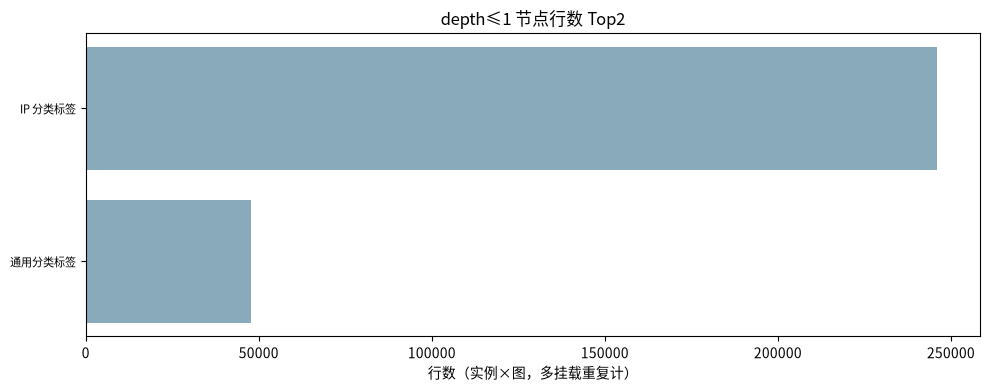

===== 节点: 融合世界标签体系 / IP 分类标签（池内 202,401 张，抽样 1 行）=====


===== 节点: 融合世界标签体系 / 通用分类标签（池内 42,936 张，抽样 1 行）=====


抽样落盘: depth=4 节点 1,099 个 / 1181 行元数据 / 1098 张图（原分辨率）→ /tank/demiwtg/state/curation/taxonomy_sample_cases


In [23]:
# ---- 节点量级图 + 按节点抽样看图 ----
PLOT_DEPTH = 1          # ← 改这里：条形图聚合深度（根=0；改 1/2/3/4 看各层分布）；默认跟随 TAX_DEPTH
N_TOP_PLOT = 20         # ← 改这里：条形图展示前多少个节点
SAMPLE_NODES = None     # ← 改这里：要抽样看图的节点路径列表（须与 PLOT_DEPTH 对齐）；None=自动取行数 Top3
N_CASES      = 1        # ← 改这里：每个节点抽几张
EXPORT_DEPTH    = 4     # ← 改这里：落盘抽样聚合深度（独立于 PLOT_DEPTH；1/2/3/4 看各层）
EXPORT_PER_NODE = 1     # ← 改这里：落盘抽样每节点抽几张（不足该数则有几张抽几张）
SAMPLE_EXPORT = Path('../state/curation/taxonomy_sample_cases')  # ← 改这里：落盘抽样导出目录（原分辨率图 + metadata.jsonl）；None=不导出
EXPORT_FIELDS = ['sha256', 'instances', 'queries', 'caption']  # ← 改这里：落盘元数据保留字段（精简省 token；可加 'sample_node' 看抽样所属节点）

# 按 PLOT_DEPTH 现场重算节点（只影响本 cell 的图与抽样，不动上一格 per_node 的 TAX_DEPTH 聚合）
_plot_node = tp.paths.str.split(' / ').str[:PLOT_DEPTH + 1].str.join(' / ')
per_plot = tp.groupby(_plot_node).agg(
    行数=('sha256', 'size'), 图片数=('sha256', 'nunique'), 实例数=('instance', 'nunique'))
per_plot['占比%'] = (100 * per_plot.行数 / max(len(tp), 1)).round(1)
per_plot = per_plot.sort_values('行数', ascending=False)

top = per_plot.head(N_TOP_PLOT)
plt.figure(figsize=(10, max(4, len(top) * 0.3)))
plt.barh(range(len(top)), top.行数.values[::-1], color='#8ab')
plt.yticks(range(len(top)), [n.split(' / ')[-1] for n in top.index[::-1]], fontsize=8)
plt.xlabel('行数（实例×图，多挂载重复计）')
plt.title(f'depth≤{PLOT_DEPTH} 节点行数 Top{len(top)}' + (f'（子树: {NODE_PATH}）' if NODE_PATH else ''))
plt.tight_layout(); plt.show()

nodes = SAMPLE_NODES if SAMPLE_NODES is not None else list(per_plot.head(3).index)
show_fields = ['instances', 'source', 'kb_match', 'identity', 'focus', 'quality', 'caption']
for nd in nodes:
    shas_pool = tp.loc[_plot_node == nd, 'sha256'].unique()
    if len(shas_pool) == 0:
        print(f'节点无数据: {nd}'); continue
    rng = np.random.default_rng(42)
    shas = list(rng.choice(shas_pool, size=min(N_CASES, len(shas_pool)), replace=False))
    in_list = ','.join(f"'{s}'" for s in shas)
    sub = mcon.execute(
        f"SELECT * FROM read_json_auto('{M_META}', maximum_object_size=1073741824)"
        f" WHERE sha256 IN ({in_list}) AND {FILTER_SQL}").df()
    print(f'===== 节点: {nd}（池内 {len(shas_pool):,} 张，抽样 {len(sub)} 行）=====')
    for _, r in sub.iterrows():
        ip = M_BASE / r['path'] if isinstance(r.get('path'), str) and (M_BASE / r['path']).is_file() else None
        img = (f'<img src="{ip}" loading="lazy" style="max-height:280px;max-width:380px;object-fit:contain;background:#f6f6f6">'
               if ip else '<div style="color:#c00">blob 缺失</div>')
        kv = ''.join(f'<div style="font-size:12px;margin:1px 0"><b>{c}</b>: {str(r.get(c))[:220]}</div>' for c in show_fields)
        display(HTML(f'<div style="display:flex;gap:12px;border:1px solid #ddd;padding:8px;margin:8px 0;align-items:flex-start">'
                     f'{img}<div style="min-width:0">{kv}</div></div>'))

# ---- 抽样落盘（独立抽样，不依赖上方展示：原分辨率图按 sha256 原样拷贝 + metadata.jsonl）----
if SAMPLE_EXPORT is not None:
    import shutil
    _exp_node = tp.paths.str.split(' / ').str[:EXPORT_DEPTH + 1].str.join(' / ')
    rng = np.random.default_rng(42)
    picks = []                       # (节点, sha256) 抽样对；池内不足 EXPORT_PER_NODE 张则有几张抽几张
    for nd, pool in tp.groupby(_exp_node)['sha256'].unique().items():
        if len(pool):
            picks += [(nd, s) for s in rng.choice(pool, size=min(EXPORT_PER_NODE, len(pool)), replace=False)]
    SAMPLE_EXPORT.mkdir(parents=True, exist_ok=True)
    recs, copied = [], {}
    all_shas = sorted({s for _, s in picks})
    frames = []                      # 分批 IN 查询，避免 SQL 过长、也避免逐节点重扫全表
    for i in range(0, len(all_shas), 500):
        in_list = ','.join(f"'{s}'" for s in all_shas[i:i+500])
        frames.append(mcon.execute(
            f"SELECT * FROM read_json_auto('{M_META}', maximum_object_size=1073741824)"
            f" WHERE sha256 IN ({in_list}) AND {FILTER_SQL}").df())
    by_sha = {s: g for s, g in pd.concat(frames).groupby('sha256')} if frames else {}
    for nd, sha in picks:
        for _, r in by_sha.get(sha, pd.DataFrame()).iterrows():
            d = {k: r[k] for k in EXPORT_FIELDS if k in r and r[k] is not None}
            ip = M_BASE / r['path'] if isinstance(r.get('path'), str) and (M_BASE / r['path']).is_file() else None
            if ip is not None:
                if sha not in copied:             # 同一图多行元数据只拷一份字节
                    dst = SAMPLE_EXPORT / f'{sha}{ip.suffix}'
                    shutil.copy2(ip, dst)
                    copied[sha] = dst.name
                d['sample_image'] = copied[sha]
            recs.append(d)
    with open(SAMPLE_EXPORT / 'metadata.jsonl', 'w', encoding='utf-8') as f:
        for d in recs:
            f.write(_json.dumps(d, ensure_ascii=False, default=str, separators=(',', ':')) + '\n')
    print(f'抽样落盘: depth={EXPORT_DEPTH} 节点 {len(set(n for n, _ in picks)):,} 个 / {len(recs)} 行元数据 / {len(copied)} 张图（原分辨率）→ {SAMPLE_EXPORT.resolve()}')


## 评测集构建（v1）

把抽样落盘目录整理成自包含评测集：图片重命名为「序号_实例名_sha 前 8 位」放入 `images/`，元数据带相对地址 `image` 字段；按 sha256 去重（同一图被多节点抽中只留一条）。整体可打包带走。


In [24]:

EVAL_SRC    = Path('../state/curation/taxonomy_sample_cases')  # ← 改这里：抽样落盘目录（上一格产物）
EVAL_OUT    = Path('../state/curation/eval_v2')                # ← 改这里：评测集输出目录（images/ + metadata.jsonl）
EVAL_FIELDS = ['sha256', 'instances', 'queries', 'caption']    # ← 改这里：评测集元数据字段（image 字段自动前置；源里有 sample_node 会自动带上）

import re, shutil, ast as _ast
def _clean(s, n=40):
    s = re.sub(r'[\\/:*?"\'<>|\s]+', '_', str(s)).strip('_')
    return s[:n] or 'noname'

(EVAL_OUT / 'images').mkdir(parents=True, exist_ok=True)
rows = [_json.loads(l) for l in open(EVAL_SRC / 'metadata.jsonl', encoding='utf-8') if l.strip()]
seen, recs = {}, []
for r in rows:
    sha = r.get('sha256')
    if not sha or sha in seen:                       # 同一图被多节点抽中/多实例多行：只留一条
        continue
    src_img = next(iter(EVAL_SRC.glob(f'{sha}.*')), None)
    if src_img is None:
        print(f'缺图跳过: {sha[:16]}…'); continue
    insts = r.get('instances')
    if isinstance(insts, str):                       # 旧版导出可能把列表经 default=str 序列化成字符串，先还原
        try: insts = _ast.literal_eval(insts)
        except Exception: pass
    inst = insts[0] if isinstance(insts, list) and insts else insts
    name = f'{len(seen)+1:04d}_{_clean(inst)}_{sha[:8]}{src_img.suffix}'
    shutil.copy2(src_img, EVAL_OUT / 'images' / name)
    d = {'image': f'images/{name}'}                  # 相对评测集根目录的地址
    for k in EVAL_FIELDS:
        v = r.get(k)
        if v is None:
            continue
        if isinstance(v, str) and v[:1] in '[{':     # 还原被序列化成字符串的列表/字典
            try: v = _ast.literal_eval(v)
            except Exception: pass
        d[k] = v
    if r.get('sample_node') is not None:
        d['sample_node'] = r['sample_node']
    seen[sha] = name
    recs.append(d)

with open(EVAL_OUT / 'metadata.jsonl', 'w', encoding='utf-8') as f:
    for d in recs:
        f.write(_json.dumps(d, ensure_ascii=False, default=str, separators=(',', ':')) + '\n')
print(f'评测集 v1: {len(recs)} 条（源 {len(rows)} 行去重后）→ {EVAL_OUT.resolve()}')
display(pd.DataFrame(recs).head(10))


评测集 v1: 1098 条（源 1181 行去重后）→ /tank/demiwtg/state/curation/eval_v2


,image,sha256,instances,queries,caption
0,images/0001_大阪环球影城_8a09539a.webp,8a09539af896e1b065fbf84d9631f184b0e3c96b9a50bc...,[大阪环球影城],{'大阪环球影城': '大阪环球影城'},这是一张大阪环球影城（Universal Studios Japan）入口处的标志性地球仪雕...
1,images/0002_安吉凯蒂猫家园_68716edf.webp,68716edf94072616b05936488cab9c712372989d720d5e...,[安吉凯蒂猫家园],{'安吉凯蒂猫家园': '安吉凯蒂猫家园'},这是一张户外实景照片，展示了安吉凯蒂猫家园内的主题景观。画面中心是一座白色的欧式镂空花架，前...
2,images/0003_小猪佩奇的玩趣世界_a51ccdf5.jpg,a51ccdf5d631224b7094aba3f2b1e5afc6d1b9b7fc154f...,[小猪佩奇的玩趣世界],{'小猪佩奇的玩趣世界': '小猪佩奇的玩趣世界'},这是一张小猪佩奇玩趣世界（Peppa Pig World of Play）室内主题乐园的实景...
3,images/0004_敦煌影视城_febed5f4.jpg,febed5f48525af98fe588a8e5b4557cdc7c8af9ec73a7d...,[敦煌影视城],{'敦煌影视城': '敦煌影视城'},这是一张敦煌影视城（敦煌古城）的实景照片。画面展示了古城内一条充满西域风情的土黄色街道，路面...
4,images/0005_威海华夏城_16c8b54a.webp,16c8b54adc8e40f37e009a55d74728e9faf9c444045802...,[威海华夏城],{'威海华夏城': '威海华夏城'},这是一张威海华夏城景区的实景照片。画面主体为景区标志性的中式牌楼，采用重檐歇山顶设计，覆盖橙...
5,images/0006_迪士尼魔法王国_92cb13bb.jpg,92cb13bb27839d53a295d3d039978f07de40b56c6b098b...,[迪士尼魔法王国],{'迪士尼魔法王国': '迪士尼魔法王国'},这是一张展示迪士尼魔法王国核心地标——灰姑娘城堡的实景照片。画面采用正面仰视构图，城堡主体巍...
6,images/0007_Comic_Market（日本Comic_Market同人志即卖会）...,532aa0c4c1da7fce974bd18bf0260e8b8cbc7f1abb2b2f...,[Comic Market（日本Comic Market同人志即卖会）],{'Comic Market（日本Comic Market同人志即卖会）': 'Comic ...,这是一张在大型室内展馆拍摄的照片，生动展现了日本Comic Market（Comiket）同...
7,images/0008_查干湖冬捕节_d9e36f8b.jpg,d9e36f8bd78676123c42b7d483b4707a348917c1c8909d...,[查干湖冬捕节],{'查干湖冬捕节': 'Chagan Lake Winter Fishing Festival'},这是一张查干湖冬捕节的高空俯瞰照片。画面中心展示了标志性的马拉绞盘起网场景，四匹装饰着彩绸的...
8,images/0009_香港动漫电玩节（ACGHK）_dffcb552.jpg,dffcb5525ce564d5b0ca4b4ec2b088dffb47d2734050c0...,[香港动漫电玩节（ACGHK）],{'香港动漫电玩节（ACGHK）': '香港动漫电玩节（ACGHK）'},这是一张在动漫展会现场拍摄的照片。背景是巨大的黄色展板，上方印有“動漫 Cosplay 大賽...
9,images/0010_秦淮灯会_7bba4a91.jpg,7bba4a91c09a085653044289474821065ce09d58f30e96...,[秦淮灯会],{'秦淮灯会': '秦淮灯会'},这是一张夜景摄影作品，画面中悬挂着大量密集的传统中式灯笼。这些灯笼呈圆柱形或扁圆形，材质看似...
